Mounted at /content/drive
✅ Libraries installed
✅ Libraries loaded
   Device : cuda
   GPU    : Tesla T4
   VRAM   : 15.6 GB
✅ Features dir : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features
✅ Figures dir  : /content/drive/MyDrive/Colab Notebooks/AIP_V2/figures
✅ Model        : Rostlab/prot_t5_xl_uniref50
✅ Batch size   : 8
✅ Pooling      : mean
✅ Half prec    : False
✅ Embedding dim: 1024 (ProtT5-XL)
✅ Parsed 2435 sequences
   Positive (AIP)    : 974
   Negative (non-AIP): 1461
   Length range      : 11 – 46 aa
Loading ProtT5 tokenizer: Rostlab/prot_t5_xl_uniref50
(First run downloads ~3 GB — cached afterwards)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/238k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/11.3G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/11.3G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
T5EncoderModel LOAD REPORT from: Rostlab/prot_t5_xl_uniref50
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✅ ProtT5 model loaded
   Model type     : T5EncoderModel (encoder only)
   Hidden size    : 1024
   Encoder layers : 24
   Attention heads: 32
Original  ( 12 aa): PRIVLDVASSVF
Processed ( 23 ch): P R I V L D V A S S V F...
Extracting ProtT5 embeddings...
  Sequences   : 2435
  Batch size  : 8
  Total batches: 305
  Pooling     : mean
  Device      : cuda

  [3/305] 24/2435 sequences done
  [6/305] 48/2435 sequences done
  [9/305] 72/2435 sequences done
  [12/305] 96/2435 sequences done
  [15/305] 120/2435 sequences done
  [18/305] 144/2435 sequences done
  [21/305] 168/2435 sequences done
  [24/305] 192/2435 sequences done
  [27/305] 216/2435 sequences done
  [30/305] 240/2435 sequences done
  [33/305] 264/2435 sequences done
  [36/305] 288/2435 sequences done
  [39/305] 312/2435 sequences done
  [42/305] 336/2435 sequences done
  [45/305] 360/2435 sequences done
  [48/305] 384/2435 sequences done
  [51/305] 408/2435 sequences done
  [54/305] 432/2435 sequences done
  [57/305] 456/243

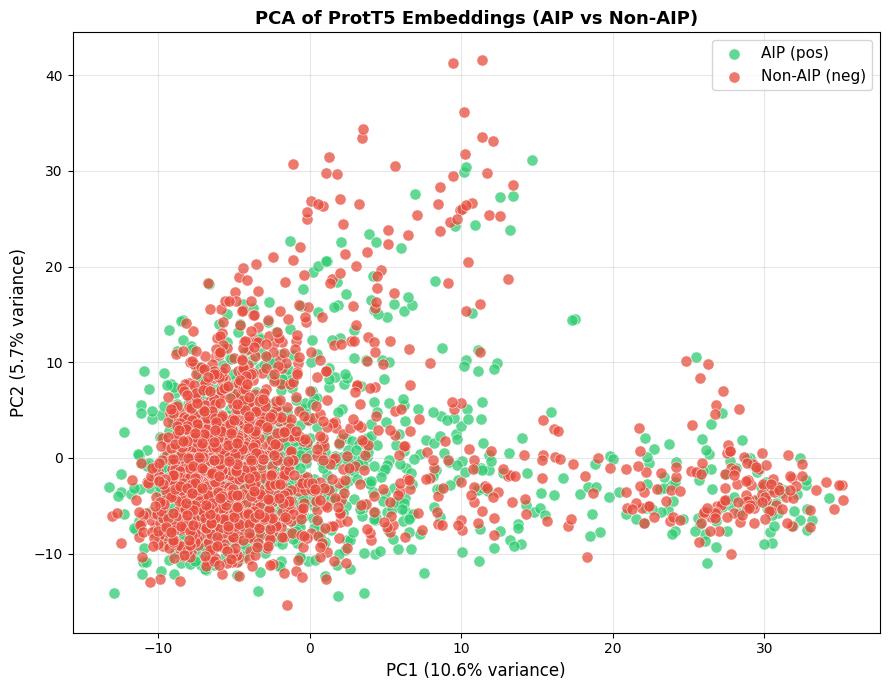

✅ PCA plot saved
Running t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


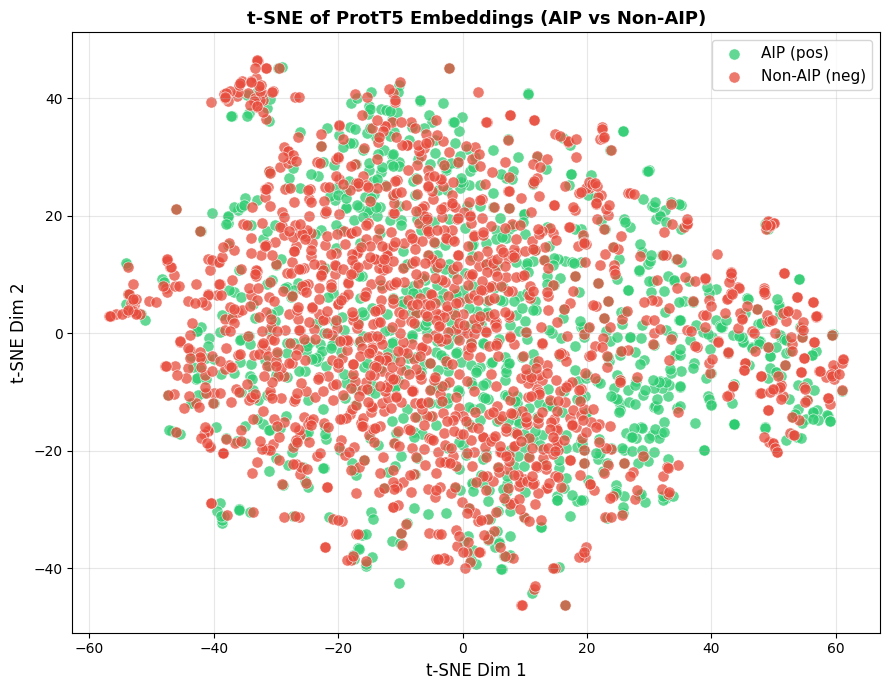

✅ t-SNE plot saved
Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


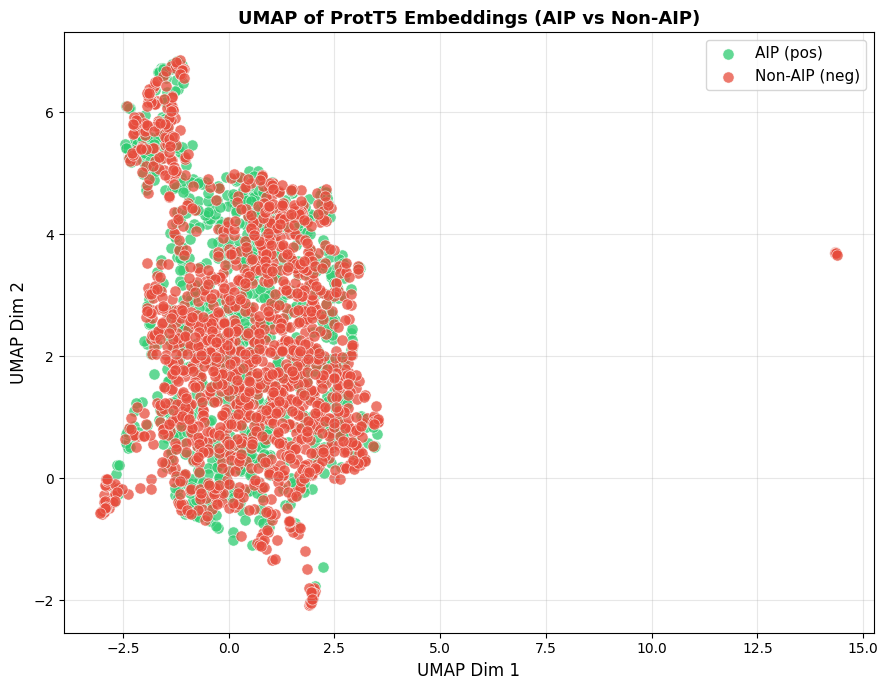

✅ UMAP plot saved
Loading ProtBERT embeddings for comparison...


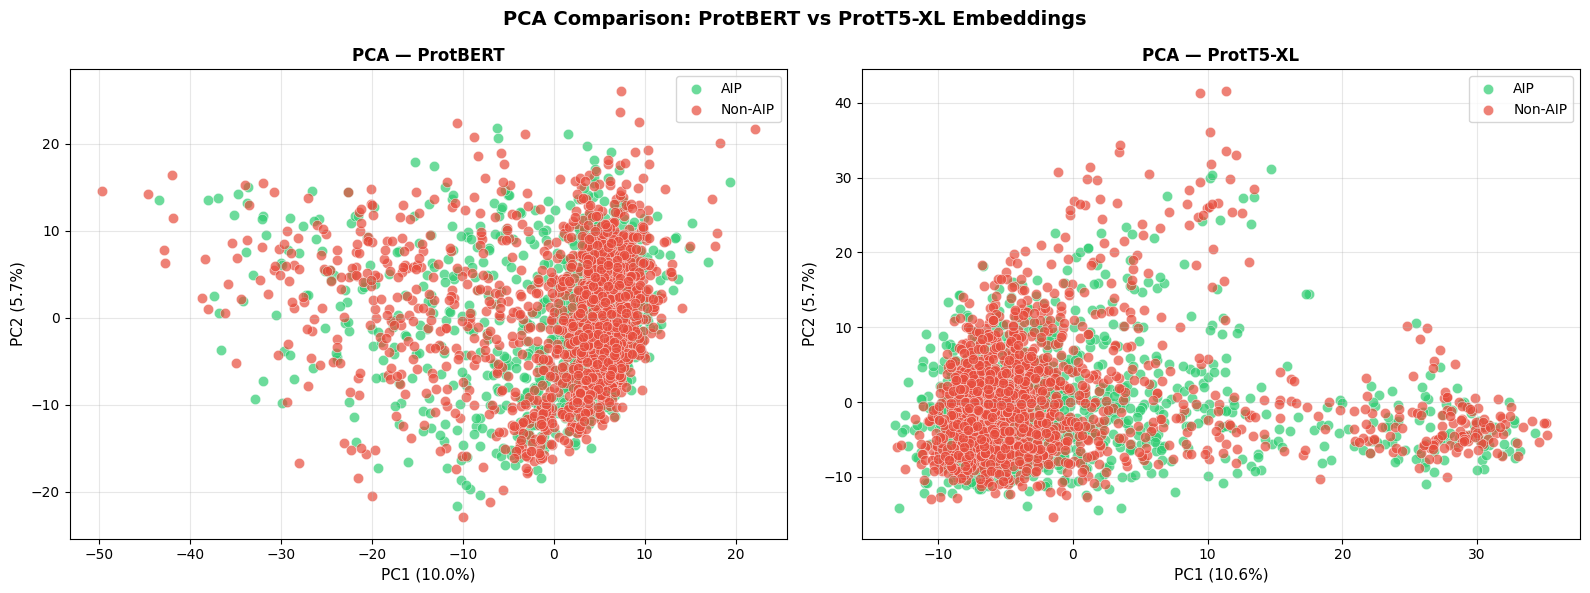

✅ ProtBERT vs ProtT5 comparison saved


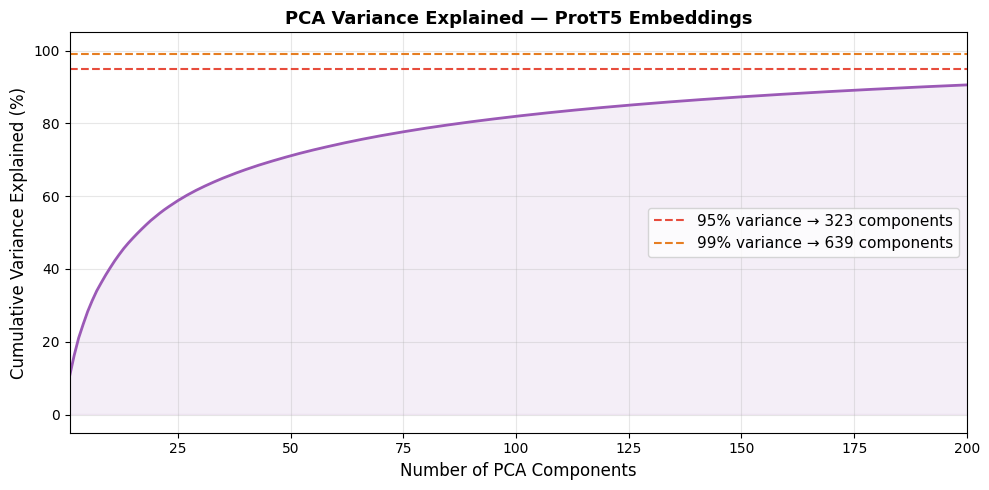

✅ Variance plot saved
   323 components → 95% variance  (vs full 1024 dims)
   639 components → 99% variance
✅ PCA-reduced features saved
   File  : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features/ProtT5_PCA_features.csv
   Shape : (2435, 326)  (323 dims vs original 1024)
✅ ProtT5 Feature Extraction COMPLETE
   Full CSV   : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features/ProtT5_features.csv
   Shape      : (2435, 1026)
   Raw .npy   : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features/ProtT5_embeddings.npy
   PCA CSV    : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features/ProtT5_PCA_features.csv
   PCA Shape  : (2435, 326)
   Figures    : /content/drive/MyDrive/Colab Notebooks/AIP_V2/figures
   Model      : Rostlab/prot_t5_xl_uniref50
   Pooling    : mean


In [1]:
# ============================================================
#   CELL 1 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
#   CELL 2 — Install Required Libraries
# ============================================================
!pip install transformers torch sentencepiece -q

print("✅ Libraries installed")


# ============================================================
#   CELL 3 — Import Libraries
# ============================================================
import os
import re
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import T5Tokenizer, T5EncoderModel
from torch.utils.data import DataLoader, Dataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# Check GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Libraries loaded")
print(f"   Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("   ⚠️  No GPU — running on CPU (slower)")


# ============================================================
#   CELL 4 — Configuration (Edit paths here)
# ============================================================

# FOR DRIVE FILE LOCATION
FASTA_PATH  = "/content/drive/MyDrive/Colab Notebooks/AIP_V2/data/AIP.fasta"
OUTPUT_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP_V2/features"
FIGURES_DIR = "/content/drive/MyDrive/Colab Notebooks/AIP_V2/figures"

# FOR LOCAL
# FASTA_PATH  = "../../data/raw/AIP_ind.fasta"
# OUTPUT_DIR  = "../../data/features"
# OUTPUT_DIR  = "../../results/figures"

OUTPUT_CSV  = os.path.join(OUTPUT_DIR, "ProtT5_features.csv")
OUTPUT_NPY  = os.path.join(OUTPUT_DIR, "ProtT5_embeddings.npy")

# ProtT5 model variants:
#   "Rostlab/prot_t5_xl_uniref50"    — trained on UniRef50  (recommended ✅)
#   "Rostlab/prot_t5_xl_bfd"         — trained on BFD database
#   "Rostlab/prot_t5_xxl_uniref50"   — larger model (needs more VRAM)
MODEL_NAME  = "Rostlab/prot_t5_xl_uniref50"

# Batch size — ProtT5 is larger than ProtBERT, use smaller batches
# T4 GPU (16 GB): BATCH_SIZE = 8
# CPU only      : BATCH_SIZE = 2
BATCH_SIZE  = 8

# Pooling strategy for fixed-size vector per sequence
#   "mean" — average over all non-padding tokens (recommended)
#   "cls"  — not standard for T5, use mean instead
POOLING     = "mean"

# Whether to use half precision (float16) to save GPU memory
# Set True if running out of GPU memory
HALF_PREC   = False

os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"✅ Features dir : {OUTPUT_DIR}")
print(f"✅ Figures dir  : {FIGURES_DIR}")
print(f"✅ Model        : {MODEL_NAME}")
print(f"✅ Batch size   : {BATCH_SIZE}")
print(f"✅ Pooling      : {POOLING}")
print(f"✅ Half prec    : {HALF_PREC}")
print(f"✅ Embedding dim: 1024 (ProtT5-XL)")


# ============================================================
#   CELL 5 — FASTA Parser
# ============================================================

def parse_fasta(filepath):
    """Parse FASTA file → DataFrame with seq_id, sequence, label"""
    entries    = []
    current_id = None

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                current_id = line[1:]
            elif line and current_id:
                label = 1 if current_id.startswith("pos") else 0
                entries.append({
                    "seq_id"  : current_id,
                    "sequence": line.upper(),
                    "label"   : label
                })

    df = pd.DataFrame(entries)
    print(f"✅ Parsed {len(df)} sequences")
    print(f"   Positive (AIP)    : {df['label'].sum()}")
    print(f"   Negative (non-AIP): {(df['label']==0).sum()}")
    print(f"   Length range      : {df['sequence'].apply(len).min()} – "
          f"{df['sequence'].apply(len).max()} aa")
    return df

df_seq = parse_fasta(FASTA_PATH)
df_seq.head(3)


# ============================================================
#   CELL 6 — Load ProtT5 Model & Tokenizer
# ============================================================
#
#  ProtT5 is a T5 encoder-decoder model pre-trained on protein
#  sequences. Key differences from ProtBERT:
#
#  ProtBERT  → BERT architecture  → 768-dim embeddings
#  ProtT5-XL → T5  architecture   → 1024-dim embeddings  ✅ better
#
#  For feature extraction we ONLY use the encoder part,
#  which is more efficient and gives better representations.
#
#  ⚠️  ProtT5 requires:
#    1. Spaces between amino acids: "ACDE" → "A C D E"
#    2. Replace rare AAs (U,Z,O,B) with X
#    3. Use T5Tokenizer (not BertTokenizer)
#
# ============================================================

print(f"Loading ProtT5 tokenizer: {MODEL_NAME}")
print("(First run downloads ~3 GB — cached afterwards)\n")

tokenizer = T5Tokenizer.from_pretrained(
    MODEL_NAME,
    do_lower_case = False,
    legacy        = True    # avoids deprecation warnings
)

print(f"Loading ProtT5 encoder model...")
model = T5EncoderModel.from_pretrained(MODEL_NAME)

# Optional: convert to half precision to save GPU memory
if HALF_PREC and DEVICE.type == "cuda":
    model = model.half()
    print("   Using float16 (half precision)")

model = model.to(DEVICE)
model.eval()

print(f"\n✅ ProtT5 model loaded")
print(f"   Model type     : T5EncoderModel (encoder only)")
print(f"   Hidden size    : {model.config.d_model}")
print(f"   Encoder layers : {model.config.num_layers}")
print(f"   Attention heads: {model.config.num_heads}")


# ============================================================
#   CELL 7 — Sequence Preprocessing for ProtT5
# ============================================================

def preprocess_sequence(sequence):
    """
    Format a protein sequence for ProtT5:
    1. Uppercase
    2. Replace rare/non-standard AAs (U, Z, O, B) with X
    3. Insert a space between every amino acid

    "ACDEFG" → "A C D E F G"

    This space-separated format is mandatory for ProtT5.
    """
    sequence = sequence.upper()
    sequence = re.sub(r"[UZOB]", "X", sequence)
    return " ".join(list(sequence))


# Preview
sample     = df_seq["sequence"].iloc[0]
processed  = preprocess_sequence(sample)
print(f"Original  ({len(sample):>3d} aa): {sample}")
print(f"Processed ({len(processed):>3d} ch): {processed[:60]}...")


# ============================================================
#   CELL 8 — PyTorch Dataset
# ============================================================

class PeptideDataset(Dataset):
    """Dataset for batched ProtT5 inference."""

    def __init__(self, sequences, tokenizer, max_length=512):
        # Preprocess all sequences upfront
        self.sequences  = [preprocess_sequence(s) for s in sequences]
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.sequences[idx],
            return_tensors     = "pt",
            padding            = "max_length",
            truncation         = True,
            max_length         = self.max_length,
            add_special_tokens = True
        )
        return {
            "input_ids"     : encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
        }


# ============================================================
#   CELL 9 — ProtT5 Embedding Extraction
# ============================================================

def pool_embeddings(hidden_states, attention_mask, strategy="mean"):
    """
    Pool token-level embeddings → fixed-size sequence vector.

    For ProtT5:
      - hidden_states shape: (batch, seq_len, 1024)
      - attention_mask shape: (batch, seq_len)

    Mean pooling is strongly recommended for ProtT5 over CLS
    because T5 does not have a dedicated classification token.
    """
    if strategy == "mean":
        mask           = attention_mask.unsqueeze(-1).float()
        sum_embeddings = (hidden_states * mask).sum(dim=1)
        count_tokens   = mask.sum(dim=1).clamp(min=1e-9)
        return sum_embeddings / count_tokens

    elif strategy == "max":
        mask = attention_mask.unsqueeze(-1).float()
        hidden_states = hidden_states.masked_fill(mask == 0, -1e9)
        return hidden_states.max(dim=1).values

    else:
        raise ValueError(f"Unknown pooling: {strategy}. Use 'mean' or 'max'.")


def extract_prott5_embeddings(df, tokenizer, model, device,
                               batch_size=BATCH_SIZE,
                               pooling=POOLING):
    """
    Extract ProtT5 embeddings for all sequences in batches.

    Returns:
        embeddings : np.ndarray of shape (N, 1024)
    """
    sequences     = df["sequence"].tolist()
    dataset       = PeptideDataset(sequences, tokenizer)
    loader        = DataLoader(dataset, batch_size=batch_size,
                               shuffle=False, num_workers=0)

    all_embeddings = []
    total_batches  = len(loader)

    print(f"Extracting ProtT5 embeddings...")
    print(f"  Sequences   : {len(sequences)}")
    print(f"  Batch size  : {batch_size}")
    print(f"  Total batches: {total_batches}")
    print(f"  Pooling     : {pooling}")
    print(f"  Device      : {device}\n")

    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):

            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            # ✅ ProtT5 encoder-only forward pass
            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask
            )

            # last_hidden_state: (batch, seq_len, 1024)
            hidden_states = outputs.last_hidden_state

            # Cast back to float32 if using half precision
            if HALF_PREC:
                hidden_states = hidden_states.float()

            # Pool → (batch, 1024)
            pooled = pool_embeddings(
                hidden_states, attention_mask, strategy=pooling
            )

            all_embeddings.append(pooled.cpu().numpy())

            # Progress
            if (batch_idx + 1) % 3 == 0 or \
               (batch_idx + 1) == total_batches:
                done = min((batch_idx + 1) * batch_size, len(sequences))
                print(f"  [{batch_idx+1}/{total_batches}] "
                      f"{done}/{len(sequences)} sequences done")

            # Free GPU cache periodically
            if DEVICE.type == "cuda" and (batch_idx + 1) % 10 == 0:
                torch.cuda.empty_cache()
                gc.collect()

    embeddings = np.vstack(all_embeddings)
    print(f"\n✅ Embedding extraction complete")
    print(f"   Shape : {embeddings.shape}")
    return embeddings


embeddings = extract_prott5_embeddings(
    df_seq, tokenizer, model, DEVICE
)


# ============================================================
#   CELL 10 — Build Feature DataFrame
# ============================================================

embedding_dim = embeddings.shape[1]   # 1024 for ProtT5-XL
col_names     = [f"ProtT5_{i}" for i in range(embedding_dim)]

df_emb = pd.DataFrame(embeddings, columns=col_names)

df_prott5 = pd.concat([
    df_seq[["seq_id", "sequence", "label"]].reset_index(drop=True),
    df_emb
], axis=1)
# ── REMOVED ──────────────────────────────────────────────
# df_prott5.insert(2, "length", df_prott5["sequence"].apply(len))
# ─────────────────────────────────────────────────────────────────

# ── CHANGED (Block): drop sequence & length, move label to end ──
df_prott5 = df_prott5.drop(columns=["sequence"])                        # ← remove sequence column
cols   = [c for c in df_prott5.columns if c != "label"] + ["label"] # ← move label to end
df_prott5 = df_prott5[cols]                                             # ← reorder columns
# ────────────────────────────────────────────────────────────────

emb_cols = [c for c in df_prott5.columns if c.startswith("ProtT5_")]

print(f"✅ Feature DataFrame built")
print(f"   Shape   : {df_prott5.shape}")
print(f"      Columns : seq_id, ProtT5_0...ProtT5_1023 (1024 features), label")  # ← CHANGED: updated column description
df_prott5.iloc[:3, :8]


# ============================================================
#   CELL 11 — Validate Output
# ============================================================

print("── Validation ──────────────────────────────────────")
print(f"Embedding dimension  : {len(emb_cols)}")
print(f"Missing values       : {df_prott5[emb_cols].isnull().sum().sum()}")
print(f"Value range          : {df_prott5[emb_cols].values.min():.4f} – "
      f"{df_prott5[emb_cols].values.max():.4f}")
print(f"Mean (pos class)     : {df_prott5[df_prott5['label']==1][emb_cols].values.mean():.6f}")
print(f"Mean (neg class)     : {df_prott5[df_prott5['label']==0][emb_cols].values.mean():.6f}")
print(f"Std  (pos class)     : {df_prott5[df_prott5['label']==1][emb_cols].values.std():.6f}")
print(f"Std  (neg class)     : {df_prott5[df_prott5['label']==0][emb_cols].values.std():.6f}")
print("✅ Validation complete")


# ============================================================
#   CELL 12 — Preprocessing for Visualizations
# ============================================================

print("Scaling embeddings for visualization...")
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_prott5[emb_cols].values)
print(f"✅ Scaled: mean≈0, std≈1  shape={X_scaled.shape}")


# ============================================================
#   CELL 13 — Visualization 1: PCA 2D Plot
# ============================================================

pca_2d  = PCA(n_components=2, random_state=42)
X_pca   = pca_2d.fit_transform(X_scaled)
var_exp = pca_2d.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 7))

for label, color, name in [(1, "#2ecc71", "AIP (pos)"),
                            (0, "#e74c3c", "Non-AIP (neg)")]:
    mask = df_prott5["label"] == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=name, alpha=0.75,
               s=65, edgecolors="white", linewidths=0.5)

ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% variance)", fontsize=12)
ax.set_title("PCA of ProtT5 Embeddings (AIP vs Non-AIP)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ProtT5_PCA.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ PCA plot saved")


# ============================================================
#   CELL 14 — Visualization 2: t-SNE 2D Plot
# ============================================================

print("Running t-SNE...")
tsne   = TSNE(n_components=2, random_state=42,
              perplexity=30, n_iter=1000, verbose=0)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))

for label, color, name in [(1, "#2ecc71", "AIP (pos)"),
                            (0, "#e74c3c", "Non-AIP (neg)")]:
    mask = df_prott5["label"] == label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=color, label=name, alpha=0.75,
               s=65, edgecolors="white", linewidths=0.5)

ax.set_xlabel("t-SNE Dim 1", fontsize=12)
ax.set_ylabel("t-SNE Dim 2", fontsize=12)
ax.set_title("t-SNE of ProtT5 Embeddings (AIP vs Non-AIP)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ProtT5_tSNE.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ t-SNE plot saved")


# ============================================================
#   CELL 15 — Visualization 3: UMAP 2D Plot
# ============================================================

try:
    import umap
except ImportError:
    print("Installing umap-learn...")
    import subprocess
    subprocess.run(["pip", "install", "umap-learn", "-q"])
    import umap

print("Running UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42,
                    n_neighbors=15, min_dist=0.1)
X_umap  = reducer.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))

for label, color, name in [(1, "#2ecc71", "AIP (pos)"),
                            (0, "#e74c3c", "Non-AIP (neg)")]:
    mask = df_prott5["label"] == label
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=color, label=name, alpha=0.75,
               s=65, edgecolors="white", linewidths=0.5)

ax.set_xlabel("UMAP Dim 1", fontsize=12)
ax.set_ylabel("UMAP Dim 2", fontsize=12)
ax.set_title("UMAP of ProtT5 Embeddings (AIP vs Non-AIP)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ProtT5_UMAP.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ UMAP plot saved")


# ============================================================
#   CELL 16 — Visualization 4: ProtBERT vs ProtT5 Comparison
#             (PCA side-by-side if ProtBERT embeddings exist)
# ============================================================

protbert_npy = os.path.join(OUTPUT_DIR, "ProtBERT_embeddings.npy")

if os.path.exists(protbert_npy):
    print("Loading ProtBERT embeddings for comparison...")
    emb_bert   = np.load(protbert_npy)
    scaler_b   = StandardScaler()
    X_bert_sc  = scaler_b.fit_transform(emb_bert)

    pca_bert   = PCA(n_components=2, random_state=42)
    X_pca_bert = pca_bert.fit_transform(X_bert_sc)
    var_bert   = pca_bert.explained_variance_ratio_

    pca_t5     = PCA(n_components=2, random_state=42)
    X_pca_t5   = pca_t5.fit_transform(X_scaled)
    var_t5     = pca_t5.explained_variance_ratio_

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, X_plot, var, title in [
        (axes[0], X_pca_bert, var_bert, "ProtBERT"),
        (axes[1], X_pca_t5,  var_t5,   "ProtT5-XL")
    ]:
        for label, color, name in [(1, "#2ecc71", "AIP"),
                                    (0, "#e74c3c", "Non-AIP")]:
            mask = df_prott5["label"] == label
            ax.scatter(X_plot[mask, 0], X_plot[mask, 1],
                       c=color, label=name, alpha=0.7,
                       s=55, edgecolors="white", linewidths=0.4)
        ax.set_xlabel(f"PC1 ({var[0]*100:.1f}%)", fontsize=11)
        ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)", fontsize=11)
        ax.set_title(f"PCA — {title}", fontsize=12, fontweight="bold")
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)

    plt.suptitle("PCA Comparison: ProtBERT vs ProtT5-XL Embeddings",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "ProtBERT_vs_ProtT5_PCA.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ ProtBERT vs ProtT5 comparison saved")
else:
    print("ℹ️  ProtBERT embeddings not found — skipping comparison plot")
    print(f"   Run 07_ProtBERT_feature_extraction.py first to enable this")


# ============================================================
#   CELL 17 — Visualization 5: PCA Variance Explained
# ============================================================

pca_full  = PCA(random_state=42)
pca_full.fit(X_scaled)
cum_var   = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_95      = np.argmax(cum_var >= 95) + 1
n_99      = np.argmax(cum_var >= 99) + 1

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(1, len(cum_var) + 1), cum_var,
        color="#9b59b6", linewidth=2)
ax.axhline(95, color="#e74c3c", linestyle="--",
           label=f"95% variance → {n_95} components")
ax.axhline(99, color="#e67e22", linestyle="--",
           label=f"99% variance → {n_99} components")
ax.axvline(n_95, color="#e74c3c", linestyle="--", alpha=0.5)
ax.axvline(n_99, color="#e67e22", linestyle="--", alpha=0.5)
ax.fill_between(range(1, len(cum_var) + 1), cum_var,
                alpha=0.1, color="#9b59b6")

ax.set_xlabel("Number of PCA Components", fontsize=12)
ax.set_ylabel("Cumulative Variance Explained (%)", fontsize=12)
ax.set_title("PCA Variance Explained — ProtT5 Embeddings",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(1, min(200, len(cum_var)))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ProtT5_PCA_variance.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ Variance plot saved")
print(f"   {n_95} components → 95% variance  (vs full {embedding_dim} dims)")
print(f"   {n_99} components → 99% variance")


# ============================================================
#   CELL 18 — Optional: PCA-Compressed Features (95% variance)
# ============================================================

pca_red   = PCA(n_components=n_95, random_state=42)
X_reduced = pca_red.fit_transform(X_scaled)

col_r        = [f"ProtT5_PCA_{i}" for i in range(n_95)]
df_reduced   = pd.DataFrame(X_reduced, columns=col_r)
df_pca_final = pd.concat([
    df_seq[["seq_id", "sequence", "label"]].reset_index(drop=True),
    df_reduced
], axis=1)

pca_csv = os.path.join(OUTPUT_DIR, "ProtT5_PCA_features.csv")
df_pca_final.to_csv(pca_csv, index=False)

print(f"✅ PCA-reduced features saved")
print(f"   File  : {pca_csv}")
print(f"   Shape : {df_pca_final.shape}  "
      f"({n_95} dims vs original {embedding_dim})")


# ============================================================
#   CELL 19 — Save Final Outputs
# ============================================================

# Full feature CSV
df_prott5.to_csv(OUTPUT_CSV, index=False)

# Raw numpy array — fastest to reload for DL pipelines
np.save(OUTPUT_NPY, embeddings)

print("=" * 55)
print("✅ ProtT5 Feature Extraction COMPLETE")
print(f"   Full CSV   : {OUTPUT_CSV}")
print(f"   Shape      : {df_prott5.shape}")
print(f"   Raw .npy   : {OUTPUT_NPY}")
print(f"   PCA CSV    : {pca_csv}")
print(f"   PCA Shape  : {df_pca_final.shape}")
print(f"   Figures    : {FIGURES_DIR}")
print(f"   Model      : {MODEL_NAME}")
print(f"   Pooling    : {POOLING}")
print("=" * 55)